In [4]:
import pandas as pd
import numpy as np

# Load the data
df = pd.read_csv('../data/Global Superstore.csv', encoding='latin1')

# Basic overview
print(df.shape)
print(df.info())
print(df.head())

(51290, 27)
<class 'pandas.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Category        51290 non-null  str    
 1   City            51290 non-null  str    
 2   Country         51290 non-null  str    
 3   Customer ID     51290 non-null  str    
 4   Customer Name   51290 non-null  str    
 5   Discount        51290 non-null  float64
 6   Market          51290 non-null  str    
 7   ji_lu-shu       51290 non-null  int64  
 8   Order Date      51290 non-null  str    
 9   Order ID        51290 non-null  str    
 10  Order Priority  51290 non-null  str    
 11  Product ID      51290 non-null  str    
 12  Product Name    51290 non-null  str    
 13  Profit          51290 non-null  float64
 14  Quantity        51290 non-null  int64  
 15  Region          51290 non-null  str    
 16  Row ID          51290 non-null  int64  
 17  Sales           51290 non-null

In [10]:
# Missing values
print("Missing values per column:\n", df.isnull().sum())

# Duplicates
print("\nDuplicate rows:", df.duplicated().sum())

# Basic statistics for numeric columns
print("\nNumeric Summary:\n", df.describe())

# Check unique values in key columns
print("\nUnique Categories:", df['Category'].unique())
print("Unique Segments:", df['Segment'].unique())

Missing values per column:
 Category          0
City              0
Country           0
Customer ID       0
Customer Name     0
Discount          0
Market            0
ji_lu-shu         0
Order Date        0
Order ID          0
Order Priority    0
Product ID        0
Product Name      0
Profit            0
Quantity          0
Region            0
Row ID            0
Sales             0
Segment           0
Ship Date         0
Ship Mode         0
Shipping Cost     0
State             0
Sub-Category      0
Year              0
Market2           0
weeknum           0
dtype: int64

Duplicate rows: 0

Numeric Summary:
            Discount  ji_lu-shu        Profit      Quantity       Row ID  \
count  51290.000000    51290.0  51290.000000  51290.000000  51290.00000   
mean       0.142908        1.0     28.610982      3.476545  25645.50000   
std        0.212280        0.0    174.340972      2.278766  14806.29199   
min        0.000000        1.0  -6599.978000      1.000000      1.00000   
25%   

In [5]:
# 1. Drop junk column
if 'ji_lu-shu' in df.columns:
    df = df.drop(columns=['ji_lu-shu'])
    print("Dropped ji_lu-shu column")

# 2. Fix date columns (with correct names)
df['Order_Date'] = pd.to_datetime(df['Order Date'], errors='coerce')
df['Ship_Date'] = pd.to_datetime(df['Ship Date'], errors='coerce')

# 3. Create new useful columns
df['Year'] = df['Order_Date'].dt.year
df['Month'] = df['Order_Date'].dt.month
df['Profit_Margin_%'] = (df['Profit'] / df['Sales']) * 100

# Final check
print("Shape after cleaning:", df.shape)
print("\nDate columns fixed (first 5 rows):")
print(df[['Order_Date', 'Ship_Date']].head())
print("\nNew columns created successfully!")
print(df.columns.tolist()[-5:])  # show last few columns

Dropped ji_lu-shu column
Shape after cleaning: (51290, 30)

Date columns fixed (first 5 rows):
  Order_Date  Ship_Date
0 2026-07-02 2026-07-02
1 2026-07-02 2026-07-02
2 2026-07-02 2026-07-02
3 2026-07-02 2026-07-02
4 2026-07-02 2026-07-02

New columns created successfully!
['weeknum', 'Order_Date', 'Ship_Date', 'Month', 'Profit_Margin_%']


In [13]:
# Basic insights
print("Total Sales:", df['Sales'].sum().round(2))
print("Total Profit:", df['Profit'].sum().round(2))
print("Overall Profit Margin:", df['Profit_Margin_%'].mean().round(2), "%")

print("\nSales by Category:\n", df.groupby('Category')['Sales'].sum().sort_values(ascending=False))
print("\nProfit by Category:\n", df.groupby('Category')['Profit'].sum().sort_values(ascending=False))

print("\nTop 5 Products by Sales:\n", df.groupby('Product Name')['Sales'].sum().nlargest(5))

Total Sales: 12642905
Total Profit: 1467457.29
Overall Profit Margin: -inf %

Sales by Category:
 Category
Technology         4744691
Furniture          4110884
Office Supplies    3787330
Name: Sales, dtype: int64

Profit by Category:
 Category
Technology         663778.73318
Office Supplies    518473.83430
Furniture          285204.72380
Name: Profit, dtype: float64

Top 5 Products by Sales:
 Product Name
Apple Smart Phone, Full Size             86936
Cisco Smart Phone, Full Size             76441
Motorola Smart Phone, Full Size          73159
Nokia Smart Phone, Full Size             71904
Canon imageCLASS 2200 Advanced Copier    61600
Name: Sales, dtype: int64


In [6]:
# Fix Profit Margin (avoid division by zero)
df['Profit_Margin_%'] = df.apply(lambda row: (row['Profit'] / row['Sales'] * 100) 
                                 if row['Sales'] > 0 else 0, axis=1)

print("Fixed Profit Margin. New Overall Average:", df['Profit_Margin_%'].mean().round(2), "%")

# Better insights
print("\nTop 10 Products by Profit:\n", df.groupby('Product Name')['Profit'].sum().nlargest(10))
print("\nSales by Segment:\n", df.groupby('Segment')['Sales'].sum().sort_values(ascending=False))
print("\nAverage Discount by Category:\n", df.groupby('Category')['Discount'].mean().round(3))

Fixed Profit Margin. New Overall Average: 4.72 %

Top 10 Products by Profit:
 Product Name
Canon imageCLASS 2200 Advanced Copier                       25199.9280
Cisco Smart Phone, Full Size                                17238.5206
Motorola Smart Phone, Full Size                             17027.1130
Hoover Stove, Red                                           11807.9690
Sauder Classic Bookcase, Traditional                        10672.0730
Harbour Creations Executive Leather Armchair, Adjustable    10427.3260
Nokia Smart Phone, Full Size                                 9938.1955
Cisco Smart Phone, with Caller ID                            9786.6408
Nokia Smart Phone, with Caller ID                            9465.3257
Belkin Router, USB                                           8955.0180
Name: Profit, dtype: float64

Sales by Segment:
 Segment
Consumer       6508141
Corporate      3824808
Home Office    2309956
Name: Sales, dtype: int64

Average Discount by Category:
 Category
Furnit

In [7]:
# Save cleaned data
df.to_csv('../data/Global_Superstore_Cleaned.csv', index=False)
print("Cleaned dataset saved successfully!")

# Quick final check
print("Final shape:", df.shape)
print("Columns:", df.columns.tolist())

Cleaned dataset saved successfully!
Final shape: (51290, 30)
Columns: ['Category', 'City', 'Country', 'Customer ID', 'Customer Name', 'Discount', 'Market', 'Order Date', 'Order ID', 'Order Priority', 'Product ID', 'Product Name', 'Profit', 'Quantity', 'Region', 'Row ID', 'Sales', 'Segment', 'Ship Date', 'Ship Mode', 'Shipping Cost', 'State', 'Sub-Category', 'Year', 'Market2', 'weeknum', 'Order_Date', 'Ship_Date', 'Month', 'Profit_Margin_%']


In [2]:
!pip install matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable


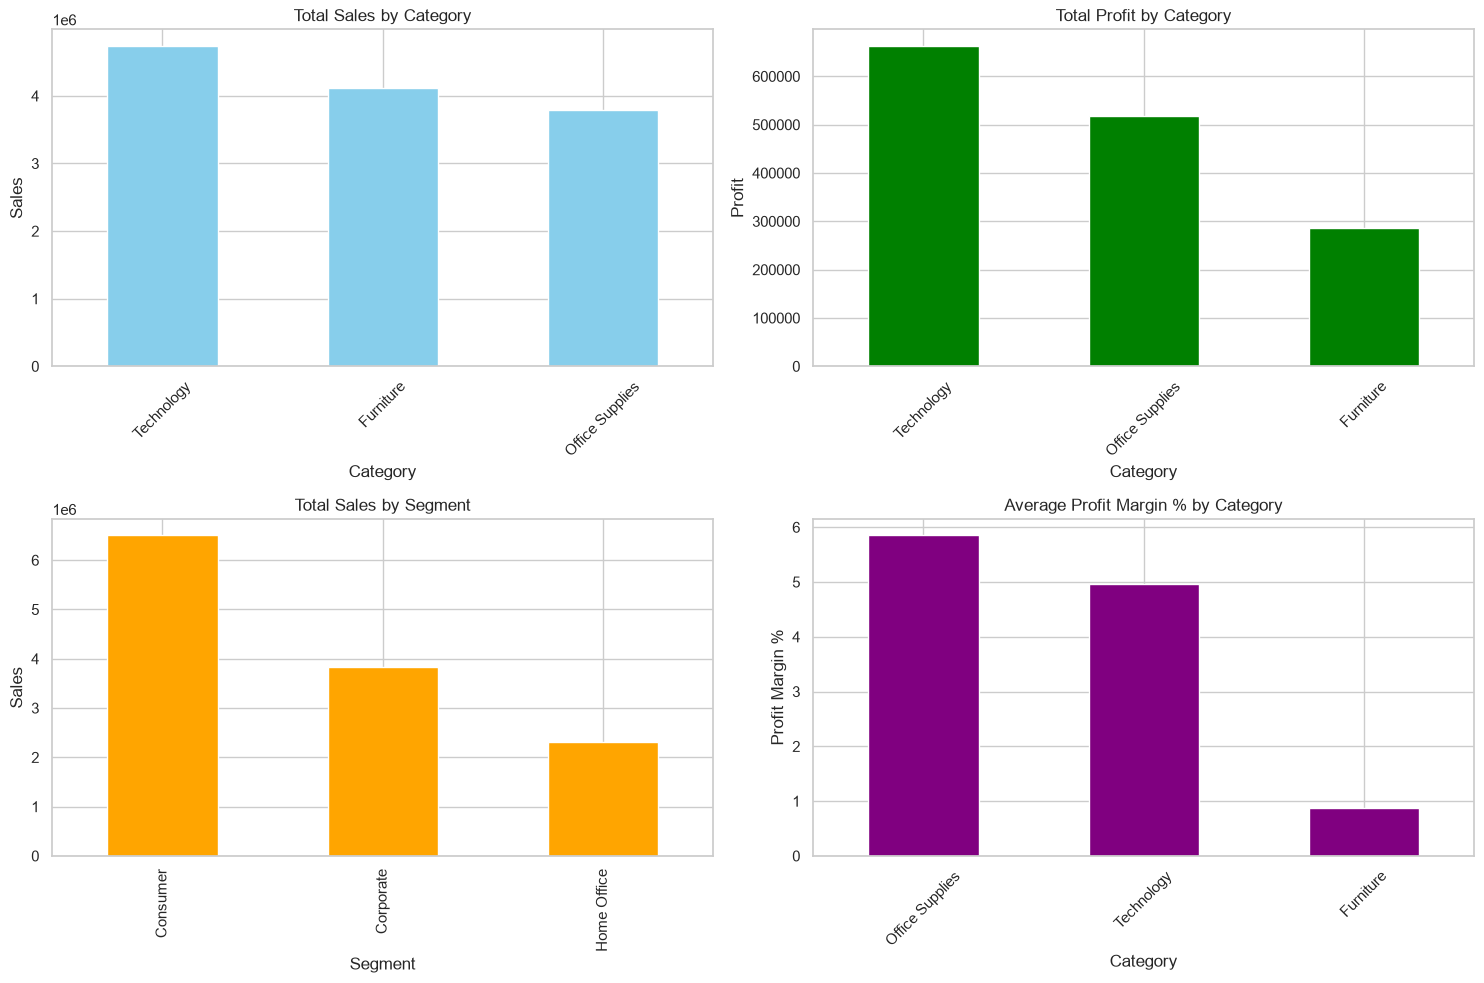

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.figure(figsize=(15, 10))

# 1. Sales by Category
plt.subplot(2, 2, 1)
df.groupby('Category')['Sales'].sum().sort_values(ascending=False).plot(kind='bar', color='skyblue')
plt.title('Total Sales by Category')
plt.ylabel('Sales')
plt.xticks(rotation=45)

# 2. Profit by Category
plt.subplot(2, 2, 2)
df.groupby('Category')['Profit'].sum().sort_values(ascending=False).plot(kind='bar', color='green')
plt.title('Total Profit by Category')
plt.ylabel('Profit')
plt.xticks(rotation=45)

# 3. Sales by Segment
plt.subplot(2, 2, 3)
df.groupby('Segment')['Sales'].sum().sort_values(ascending=False).plot(kind='bar', color='orange')
plt.title('Total Sales by Segment')
plt.ylabel('Sales')

# 4. Profit Margin by Category
plt.subplot(2, 2, 4)
df.groupby('Category')['Profit_Margin_%'].mean().sort_values(ascending=False).plot(kind='bar', color='purple')
plt.title('Average Profit Margin % by Category')
plt.ylabel('Profit Margin %')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()